In [1]:
import pandas as pd

# URLs for Patient and Sample level data
patient_url = "https://media.githubusercontent.com/media/cBioPortal/datahub/master/public/msk_impact_2017/data_clinical_patient.txt"
sample_url = "https://media.githubusercontent.com/media/cBioPortal/datahub/master/public/msk_impact_2017/data_clinical_sample.txt"

# Load both datasets
df_patient = pd.read_csv(patient_url, sep="\t", comment="#")
df_sample = pd.read_csv(sample_url, sep="\t", comment="#")

# Merge on PATIENT_ID
df_msk = pd.merge(df_patient, df_sample, on="PATIENT_ID")

print(f"Dataset shape: {df_msk.shape}")
# df_msk.head()

Dataset shape: (10945, 23)


In [2]:
import io
import tarfile
import requests
import pandas as pd

# Download MSK-IMPACT 2017 study archive from cBioPortal
archive_url = "https://datahub.assets.cbioportal.org/msk_impact_2017.tar.gz"

response = requests.get(archive_url)

with tarfile.open(fileobj=io.BytesIO(response.content), mode="r:gz") as tar:
    for member in tar.getmembers():
        if member.name.endswith("data_mutations.txt"):
            f = tar.extractfile(member)
            mut_df = pd.read_csv(f, sep="\t", comment="#", low_memory=False)
            
print(f"Loaded mutation dataset shape: {mut_df.shape}")

pd.set_option('display.max_columns', None)
display(mut_df.head(3))

print(mut_df.columns.tolist())

Loaded mutation dataset shape: (78220, 49)


,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2,dbSNP_RS,dbSNP_Val_Status,Tumor_Sample_Barcode,Matched_Norm_Sample_Barcode,Match_Norm_Seq_Allele1,Match_Norm_Seq_Allele2,Tumor_Validation_Allele1,Tumor_Validation_Allele2,Match_Norm_Validation_Allele1,Match_Norm_Validation_Allele2,Verification_Status,Validation_Status,Mutation_Status,Sequencing_Phase,Sequence_Source,Validation_Method,Score,BAM_File,Sequencer,t_ref_count,t_alt_count,n_ref_count,n_alt_count,HGVSc,HGVSp,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Hotspot,cDNA_change,genomic_location_explanation,Annotation_Status
0,SPEN,23013,NaN,GRCh37,1,16265908,16265908,+,missense_variant,Missense_Mutation,SNP,A,A,T,NaN,NaN,P-0000004-T01-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400,73,NaN,NaN,ENST00000375759.3:c.10981A>T,p.Ile3661Phe,p.I3661F,ENST00000375759,NM_015001.2,3661.0,Att/Ttt,15/15,0,c.10981A>T,NaN,SUCCESS
1,ALK,238,NaN,GRCh37,2,29543736,29543736,+,missense_variant,Missense_Mutation,SNP,A,A,G,rs35093491,NaN,P-0000004-T01-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180,13,NaN,NaN,ENST00000389048.3:c.1427T>C,p.Val476Ala,p.V476A,ENST00000389048,NM_004304.4,476.0,gTg/gCg,29-Jul,0,c.1427T>C,NaN,SUCCESS
2,PDCD1,5133,NaN,GRCh37,2,242793433,242793433,+,missense_variant,Missense_Mutation,SNP,G,G,A,rs2227982,NaN,P-0000004-T01-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225,15,NaN,NaN,ENST00000334409.5:c.644C>T,p.Ala215Val,p.A215V,ENST00000334409,NM_005018.2,215.0,gCc/gTc,5-May,0,c.644C>T,NaN,SUCCESS


['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome', 'Start_Position', 'End_Position', 'Strand', 'Consequence', 'Variant_Classification', 'Variant_Type', 'Reference_Allele', 'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2', 'dbSNP_RS', 'dbSNP_Val_Status', 'Tumor_Sample_Barcode', 'Matched_Norm_Sample_Barcode', 'Match_Norm_Seq_Allele1', 'Match_Norm_Seq_Allele2', 'Tumor_Validation_Allele1', 'Tumor_Validation_Allele2', 'Match_Norm_Validation_Allele1', 'Match_Norm_Validation_Allele2', 'Verification_Status', 'Validation_Status', 'Mutation_Status', 'Sequencing_Phase', 'Sequence_Source', 'Validation_Method', 'Score', 'BAM_File', 'Sequencer', 't_ref_count', 't_alt_count', 'n_ref_count', 'n_alt_count', 'HGVSc', 'HGVSp', 'HGVSp_Short', 'Transcript_ID', 'RefSeq', 'Protein_position', 'Codons', 'Exon_Number', 'Hotspot', 'cDNA_change', 'genomic_location_explanation', 'Annotation_Status']


In [3]:
# Count one mutation per gene per patient
unique_muts = mut_df[['Tumor_Sample_Barcode', 'Hugo_Symbol']].drop_duplicates()

# Count how many unique patients have a mutation for each gene to find top 10
top_10_genes = unique_muts['Hugo_Symbol'].value_counts().head(10).index.tolist()

print(top_10_genes)

['TP53', 'KRAS', 'TERT', 'PIK3CA', 'APC', 'ARID1A', 'KMT2D', 'PTEN', 'KMT2C', 'EGFR']


In [5]:
# Filter the mutation dataframe to only include rows for these top 10 genes
filtered_muts = mut_df[mut_df['Hugo_Symbol'].isin(top_10_genes)]
print(f"Filtered mutation dataset shape: {filtered_muts.shape}")



Filtered mutation dataset shape: (16028, 49)


In [8]:
# Transform mutation data into one patient per row, one gene per column format (binary mutation matrix)
# (1 = mutated, 0 = wild-type)
# Rows = samples, columns = genes
gene_matrix = pd.crosstab(filtered_muts['Tumor_Sample_Barcode'], filtered_muts['Hugo_Symbol'])
gene_matrix = (gene_matrix > 0).astype(int)

# Add mut prefix to the column names for easy filtering later
gene_matrix.columns = [f"mut_{gene}" for gene in gene_matrix.columns]

# Merge mutation matrix with the combined dataframe from earlier (df_msk)
merge_col = 'SAMPLE_ID'

df_final = df_msk.merge(gene_matrix, left_on=merge_col, right_index=True, how='left')

mut_cols = df_final.filter(regex = '^mut_').columns

# Missing mutation values = 0
df_final[mut_cols] = df_final[mut_cols].fillna(0).astype(int)

print(f"Final merged dataset shape: {df_final.shape}")
print(df_final.head(5))

Final merged dataset shape: (10945, 33)
  PATIENT_ID     SEX VITAL_STATUS   SMOKING_HISTORY  OS_MONTHS   OS_STATUS  \
0  P-0000004  Female        ALIVE           Unknown        NaN    0:LIVING   
1  P-0000015  Female     DECEASED             Never        NaN  1:DECEASED   
2  P-0000023    Male     DECEASED             Never       8.71  1:DECEASED   
3  P-0000024  Female        ALIVE  Prev/Curr Smoker      36.75    0:LIVING   
4  P-0000025  Female        ALIVE             Never       8.81    0:LIVING   

           SAMPLE_ID SAMPLE_COLLECTION_SOURCE SPECIMEN_PRESERVATION_TYPE  \
0  P-0000004-T01-IM3                  Outside                       FFPE   
1  P-0000015-T01-IM3                 In-House                       FFPE   
2  P-0000023-T01-IM3                 In-House                       FFPE   
3  P-0000024-T01-IM3                 In-House                       FFPE   
4  P-0000025-T02-IM5                 In-House                       FFPE   

  SPECIMEN_TYPE  DNA_INPUT  SAMPLE

In [9]:
# Check final merged dataset
print(df_final.info())
print(df_final.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10945 entries, 0 to 10944
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PATIENT_ID                  10945 non-null  object 
 1   SEX                         10945 non-null  object 
 2   VITAL_STATUS                10943 non-null  object 
 3   SMOKING_HISTORY             10943 non-null  object 
 4   OS_MONTHS                   8142 non-null   float64
 5   OS_STATUS                   10943 non-null  object 
 6   SAMPLE_ID                   10945 non-null  object 
 7   SAMPLE_COLLECTION_SOURCE    10945 non-null  object 
 8   SPECIMEN_PRESERVATION_TYPE  10945 non-null  object 
 9   SPECIMEN_TYPE               10944 non-null  object 
 10  DNA_INPUT                   10944 non-null  float64
 11  SAMPLE_COVERAGE             10944 non-null  float64
 12  TUMOR_PURITY                10474 non-null  float64
 13  MATCHED_STATUS              109

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

df_final.describe()

top_5_types = df_final['CANCER_TYPE'].value_counts().head(10).index.tolist()
cancer_type_df = df_final[df_final['CANCER_TYPE'].isin(top_5_types)]
print(cancer_type_df.shape)

(7375, 33)


C:\Users\linds\AppData\Local\Temp\ipykernel_23344\3123961682.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


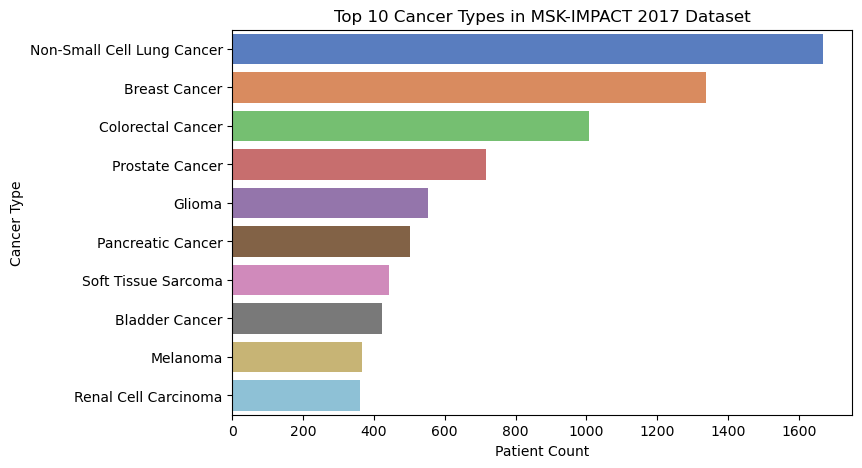

In [11]:
plt.figure(figsize=(8, 5))

# Check top cancer types visually
sns.countplot(
    data=cancer_type_df,
    y="CANCER_TYPE",
    order=cancer_type_df["CANCER_TYPE"].value_counts().index,
    palette="muted",
)

plt.title('Top 10 Cancer Types in MSK-IMPACT 2017 Dataset')
plt.xlabel('Patient Count')
plt.ylabel('Cancer Type')
plt.show()

C:\Users\linds\AppData\Local\Temp\ipykernel_23344\4144699576.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


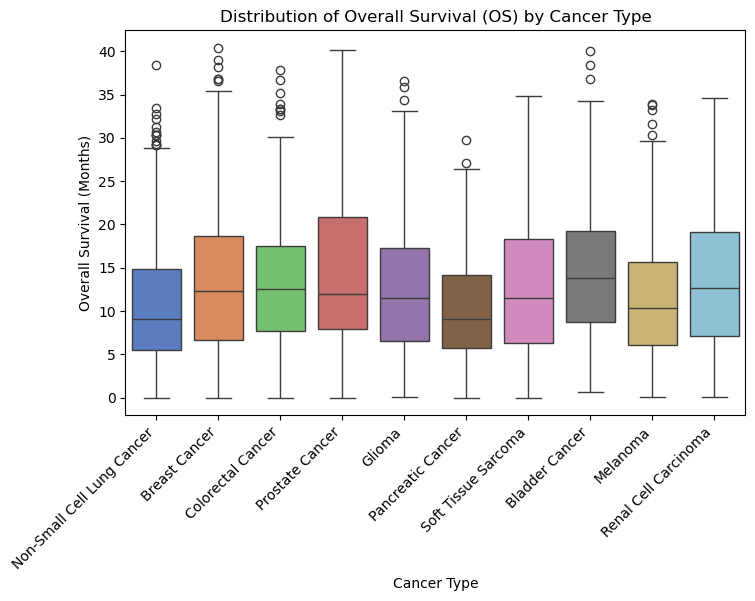

In [12]:
plt.figure(figsize=(8, 5))

# Check distribution of OS by cancer type visually
sns.boxplot(
    data=cancer_type_df, 
    x='CANCER_TYPE', 
    y='OS_MONTHS', 
    order=cancer_type_df['CANCER_TYPE'].value_counts().head(10).index, # Keeps only the top 10 ordered by frequency
    palette='muted'
)

plt.title('Distribution of Overall Survival (OS) by Cancer Type')
plt.xlabel('Cancer Type')
plt.ylabel('Overall Survival (Months)')
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.show()

C:\Users\linds\AppData\Local\Temp\ipykernel_23344\4240483362.py:21: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


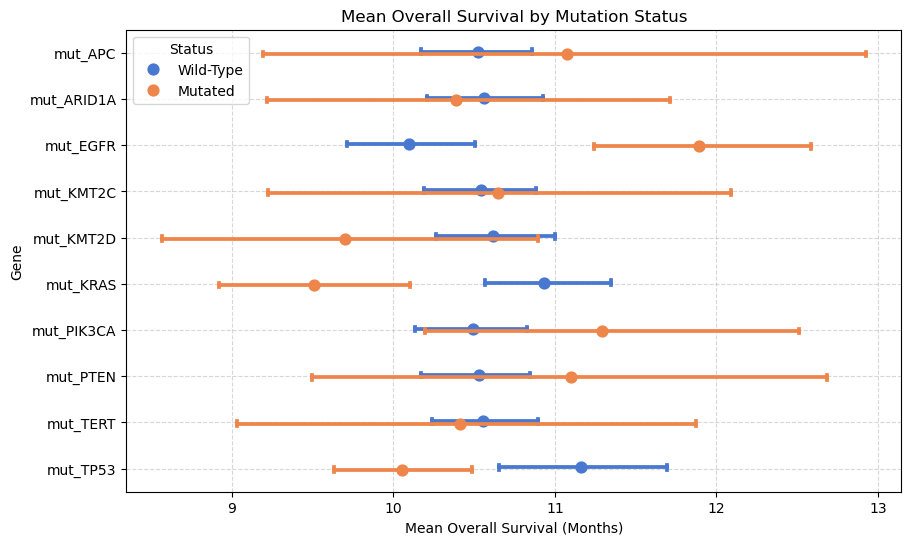

In [14]:
# Filter for NSCLC
single_cancer_df = cancer_type_df[cancer_type_df['CANCER_TYPE'] == 'Non-Small Cell Lung Cancer'].copy()

# Melt mutation columns into a single 'Gene' and 'Status' column
#mutations_to_check = ['mut_TP53', 'mut_KRAS', 'mut_EGFR']
mutations_to_check = [col for col in single_cancer_df.columns if col.startswith("mut_")]

melted_df = pd.melt(
    single_cancer_df,
    id_vars=['OS_MONTHS'],                  
    value_vars= mutations_to_check,          
    var_name='Gene',                        
    value_name='Mutation_Status'
)

# Map 1/0 to readable labels
melted_df['Mutation_Status'] = melted_df['Mutation_Status'].map({1: 'Mutated', 0: 'Wild-Type', True: 'Mutated', False: 'Wild-Type'})

plt.figure(figsize=(10, 6))

sns.pointplot(
    data=melted_df,
    y='Gene',                 
    x='OS_MONTHS',            
    hue='Mutation_Status',    
    dodge=True,               
    join=False,               
    palette='muted',
    capsize=0.1               
)

plt.title('Mean Overall Survival by Mutation Status')
plt.xlabel('Mean Overall Survival (Months)')
plt.ylabel('Gene')
plt.legend(title='Status')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

<lifelines.CoxPHFitter: fitted with 1542 total observations, 1041 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_STATUS'
      baseline estimation = breslow
   number of observations = 1542
number of events observed = 501
   partial log-likelihood = -3303.67
         time fit was run = 2026-08-13 23:39:24 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
mut_APC     0.09      1.10      0.20           -0.30            0.49                0.74                1.63
mut_ARID1A -0.05      0.95      0.16           -0.36            0.27                0.70                1.30
mut_EGFR   -0.51      0.60      0.12           -0.75           -0.28                0.47                0.76
mut_KMT2C  -0.20      0.82      0.20           -0.59            0.20                0.55                1.22
mut_KMT2D   0.34      1.40      0.15            0.04            0.64                1.04                1.89
mut_KRAS    0.11      1.12      0.11           -0.09            0.32                0.91                1.38
mut_PIK3CA -0.21      0.81      0.18           -0.57            0.16                0.57                1.17
mut_PTEN    0.04      1.04      0.23           -0.40            0.49                0.67                1.63
mut_TERT   -0.02      0.98      0.21           -0.45            0.40                0.64                1.49
mut_TP53    0.48      1.62      0.10            0.29            0.67                1.34                1.95

            cmp to     z      p  -log2(p)
covariate                                
mut_APC       0.00  0.47   0.64      0.65
mut_ARID1A    0.00 -0.30   0.76      0.39
mut_EGFR      0.00 -4.30 <0.005     15.82
mut_KMT2C     0.00 -0.97   0.33      1.59
mut_KMT2D     0.00  2.20   0.03      5.18
mut_KRAS      0.00  1.07   0.28      1.82
mut_PIK3CA    0.00 -1.12   0.26      1.92
mut_PTEN      0.00  0.19   0.85      0.24
mut_TERT      0.00 -0.11   0.91      0.14
mut_TP53      0.00  5.04 <0.005     21.05
---
Concordance = 0.59
Partial AIC = 6627.35
log-likelihood ratio test = 56.62 on 10 df
-log2(p) of ll-ratio test = 25.93

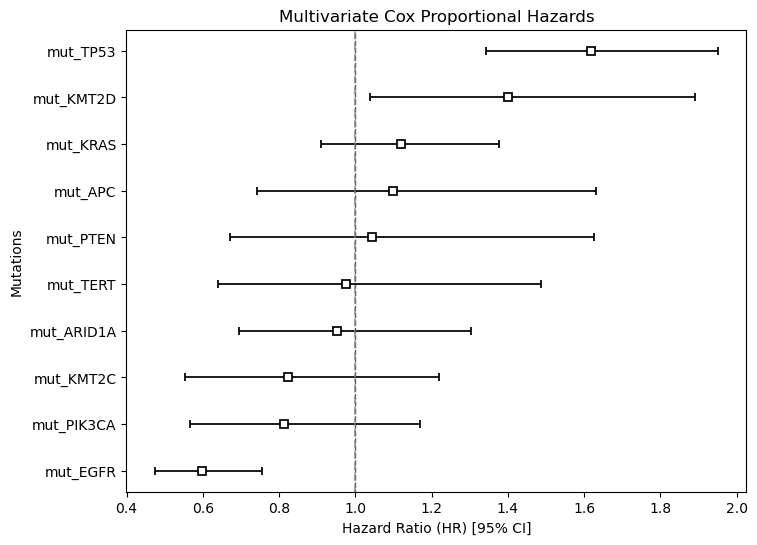

In [15]:
from lifelines import CoxPHFitter

# Isolate data for forest plot
mutations_to_check = [col for col in single_cancer_df.columns if col.startswith('mut_')]
model_df = single_cancer_df[['OS_MONTHS', 'OS_STATUS'] + mutations_to_check].copy()

# Filter out missing values
model_df = model_df.dropna(subset=['OS_MONTHS', 'OS_STATUS'])

# OS_STATUS 1=event occurred, 0=censored/alive
model_df['OS_STATUS']=model_df['OS_STATUS'].map({
    '0:LIVING': 0,
    '1:DECEASED': 1
})

# Fit Cox Proportional Hazards model
cph = CoxPHFitter()
cph.fit(model_df, duration_col='OS_MONTHS', event_col='OS_STATUS')
cph.print_summary()

# Create forest plot
plt.figure(figsize=(8, 6))

# Generate the forest plot
cph.plot(hazard_ratios=True)

plt.title('Multivariate Cox Proportional Hazards')
plt.xlabel('Hazard Ratio (HR) [95% CI]')
plt.ylabel('Mutations')
plt.axvline(1.0, color='grey', linestyle='--', alpha=0.7) # Adds the neutral reference line at 1.0
plt.show()

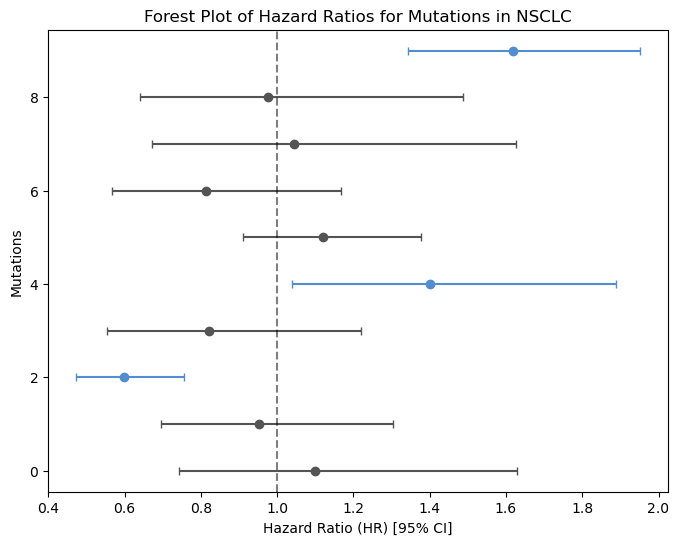

In [19]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

summary = cph.summary.copy()
y_pos = np.arange(len(summary))

for i in range(len(summary)):
    p_val = summary['p'].iloc[i]
    is_sig = summary['p'].iloc[i] < 0.05

    color = "#538dd0" if is_sig else "#555454"

    plt.errorbar(
        x = summary['exp(coef)'].iloc[i],
        y = y_pos[i],
        color = color,
        xerr = [[summary['exp(coef)'].iloc[i] - summary['exp(coef) lower 95%'].iloc[i]],
                [summary['exp(coef) upper 95%'].iloc[i] - summary['exp(coef)'].iloc[i]]],
        fmt = 'o',
        capsize = 3
    )

plt.axvline(1.0, color='black', linestyle='--', alpha=0.5)
plt.xlabel("Hazard Ratio (HR) [95% CI]")
plt.ylabel("Mutations")
plt.title('Forest Plot of Hazard Ratios for Mutations in NSCLC')
plt.show()


In [20]:
# Check that mutation effect doesn't change over time...
cph.check_assumptions(model_df, p_value_threshold=0.05)

Proportional hazard assumption looks okay.


[]

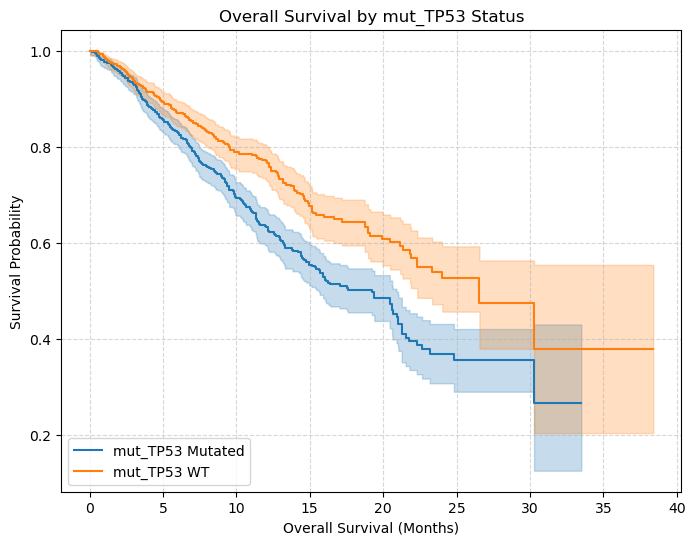

In [21]:
from lifelines import KaplanMeierFitter

# Check the statistically significant mutations (TP53, EGFR)
# MLL2 p value >0.005, won't include
gene_col = 'mut_TP53'
kmf = KaplanMeierFitter()

plt.figure(figsize=(8, 6))

# Filter and plot mutated TP53
ax = plt.subplot(111)
mutated_mask = model_df[gene_col] == 1
kmf.fit(
    durations=model_df.loc[mutated_mask, 'OS_MONTHS'], 
    event_observed=model_df.loc[mutated_mask, 'OS_STATUS'],
    label = f'{gene_col} Mutated'
)
kmf.plot_survival_function(ax=ax, ci_show=True)

# Filter and plot wild-type TP53
wt_mask = model_df[gene_col] == 0
kmf.fit(
    durations=model_df.loc[wt_mask, 'OS_MONTHS'], 
    event_observed=model_df.loc[wt_mask, 'OS_STATUS'],
    label = f'{gene_col} WT'
)
kmf.plot_survival_function(ax=ax, ci_show=True)

plt.title(f'Overall Survival by {gene_col} Status')
plt.xlabel('Overall Survival (Months)')
plt.ylabel('Survival Probability')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.show()

In [ ]:
from lifelines.statistics import logrank_test

# Check statistical significance using log-rank test